In [1]:
import pandas as pd
import numpy as np
import re
import os

In [2]:
class AgenteProcesadorEducativo:
    """
    Agente diseñado para procesar un archivo Excel (.xlsx) con múltiples pestañas
    de sistematización educativa en Google Colab.
    """

    def __init__(self, directory="/content/drive/MyDrive/ONG_data/"):
        if not directory.endswith('/'):
            directory += '/'
        self.directory = directory
        self.data_frames = {}
        self.features_report = pd.DataFrame()

    def _buscar_archivo_excel(self):
        """Busca el archivo Excel principal en el directorio."""
        if not os.path.exists(self.directory):
            print(f"❌ Error: La ruta {self.directory} no existe. Verifica el montaje de Drive.")
            return None

        for file in os.listdir(self.directory):
            # Buscamos el archivo de sistematización (Excel)
            if 'Sistematizacion' in file and file.endswith('.xlsx'):
                return os.path.join(self.directory, file)
        return None

    def cargar_datos(self):
        """Carga las pestañas específicas del archivo Excel único."""
        path = self._buscar_archivo_excel()
        if not path:
            print("❌ No se encontró el archivo Excel de 'Sistematizacion' en la carpeta.")
            return

        print(f"--- Procesando Excel: {os.path.basename(path)} ---")

        # Diccionario de pestañas que necesitamos
        sheets_to_load = {
            'ProgVSEjec_Pct': '%ProgVSEjec', # Pestaña con porcentajes directos
            'ProgVSEjec_Raw': 'ProgVSEjec',  # Pestaña con descripción de sesiones
            'Impacto': 'Impacto',
            'Lecciones': 'Lecciones',
            'Alcance': 'Alcance',             # Aqui reside el codigo modular
            'IIEE' : 'IIEE'                 # Pestaña alternativa de metadatos
        }

        try:
            excel_file = pd.ExcelFile(path)
            all_sheets = excel_file.sheet_names
            print(f"Pestañas detectadas: {all_sheets}")

            for key, sheet_name in sheets_to_load.items():
                # Buscamos la pestaña por coincidencia parcial (ignora mayúsculas/minúsculas)
                target_sheet = next((s for s in all_sheets if sheet_name.lower() in s.lower()), None)

                if target_sheet:
                    df = pd.read_excel(path, sheet_name=target_sheet)
                    # Limpieza: quitar filas vacías
                    df = df.dropna(how='all')
                    # Normalizar nombres de columnas: quitar espacios y saltos de línea
                    df.columns = [str(c).replace('\n', ' ').strip() for c in df.columns]
                    self.data_frames[key] = df
                    print(f"✅ Cargada pestaña: '{target_sheet}' como {key} ({len(df)} filas)")
                else:
                    print(f"⚠️ No se encontró la pestaña '{sheet_name}'")
            self._construir_mapa_identidad()
        except Exception as e:
            print(f"❌ Error al leer el archivo Excel: {e}")

    def _construir_mapa_identidad(self):
        """Crea una relación única entre el nombre de la IE y su Código Modular."""
        # Intentamos obtenerlo de Alcance o IIEE
        df_ref = self.data_frames.get('Alcance', self.data_frames.get('IIEE'))

        if df_ref is not None:
            try:
                col_inst = [c for c in df_ref.columns if 'Instituci' in c][0]
                col_cod = [c for c in df_ref.columns if 'Cod modular' in c or 'COD_MOD' in c or 'Modular' in c][0]

                mapa = df_ref[[col_inst, col_cod]].copy()
                mapa.columns = ['IE_ORIGINAL', 'COD_MOD']

                # Limpiar nombre para el cruce
                mapa['IE_KEY'] = mapa['IE_ORIGINAL'].apply(self.limpiar_nombre_ie)
                # Asegurar que COD_MOD sea string de 7 dígitos (formato estándar MINEDU)
                mapa['COD_MOD'] = mapa['COD_MOD'].apply(lambda x: str(int(float(x))).zfill(7) if pd.notna(x) and str(x).replace('.','').isdigit() else str(x))

                self.ie_map = mapa.drop_duplicates(subset=['IE_KEY'])
                print(f"✅ Mapa de Identidad creado: {len(self.ie_map)} códigos modulares vinculados.")
            except Exception as e:
                print(f"⚠️ No se pudo mapear el Código Modular: {e}")

    def limpiar_nombre_ie(self, nombre):
        """Normaliza el nombre de la IE para asegurar cruces exitosos."""
        if pd.isna(nombre): return "DESCONOCIDA"
        return str(nombre).strip().upper()

    def analizar_sentimiento_simple(self, texto):
        """Puntuación de sentimiento basada en palabras clave educativas."""
        texto = str(texto).lower()
        pos = ['logro', 'desarrollo', 'éxito', 'mejoró', 'participación', 'fortalecer', 'positivo']
        neg = ['desafío', 'dificultad', 'problema', 'baja', 'falta', 'limitado', 'barrera']

        score = 0
        palabras = texto.split()
        if not palabras: return 0
        for p in pos:
            if p in texto: score += 1
        for p in neg:
            if p in texto: score -= 1
        return (score / (len(palabras) + 1)) * 100

    def clasificar_desafio(self, texto):
        """Clasifica el tipo de problemática pedagógica o logística."""
        texto = str(texto).lower()
        if any(w in texto for w in ['asistencia', 'participación', 'familias']): return 'Participación'
        if any(w in texto for w in ['tiempo', 'horario', 'distancia']): return 'Logística'
        if any(w in texto for w in ['material', 'recursos', 'analfabetismo']): return 'Recursos'
        if any(w in texto for w in ['aprendizaje', 'nivel', 'pedagógico']): return 'Pedagógico'
        return 'General'

    def extraer_features_lecciones(self):
        if 'Lecciones' in self.data_frames:
            df = self.data_frames['Lecciones'].copy()
            try:
                col_inst = [c for c in df.columns if 'Instituci' in c][0]
                col_lecc = [c for c in df.columns if 'Lecciones' in c][0]
                col_desaf = [c for c in df.columns if 'Desaf' in c][0]

                df['sentimiento_leccion'] = df[col_lecc].apply(self.analizar_sentimiento_simple)
                df['categoria_desafio'] = df[col_desaf].apply(self.clasificar_desafio)
                df['IE_KEY'] = df[col_inst].apply(self.limpiar_nombre_ie)
                return df[['IE_KEY', 'sentimiento_leccion', 'categoria_desafio']]
            except Exception as e:
                print(f"⚠️ Error al extraer lecciones: {e}")
        return pd.DataFrame()

    def extraer_features_ejecucion(self):
        """Extrae ratios de la pestaña de porcentajes o calcula desde la raw."""
        # Prioridad 1: Pestaña de Porcentajes (%ProgVSEjec)
        if 'ProgVSEjec_Pct' in self.data_frames:
            df = self.data_frames['ProgVSEjec_Pct'].copy()
            col_logro = [c for c in df.columns if 'Logro' in c or '%' in c]
            # En esta pestaña no suele venir la IE directamente, sino el facilitador.
            # Si no hay IE, intentamos usar la Raw.

        # Prioridad 2: Pestaña Raw (ProgVSEjec) con cálculo manual
        if 'ProgVSEjec_Raw' in self.data_frames:
            df = self.data_frames['ProgVSEjec_Raw'].copy()
            try:
                col_inst = [c for c in df.columns if 'Instituci' in c][0]
                col_prog = [c for c in df.columns if 'Programado' in c][0]
                col_ejec = [c for c in df.columns if 'Ejecutado' in c][0]

                def extraer_numero(texto):
                    nums = re.findall(r'(\d+)', str(texto))
                    return int(nums[0]) if nums else 0

                # Calculamos el ratio sumando sesiones y talleres
                df['n_prog'] = df[col_prog].apply(extraer_numero)
                df['n_ejec'] = df[col_ejec].apply(extraer_numero)

                # Agrupar por IE para consolidar sesiones + talleres
                res = df.groupby(col_inst).agg({'n_prog': 'sum', 'n_ejec': 'sum'}).reset_index()
                res['ratio_cumplimiento'] = res.apply(lambda x: x['n_ejec']/x['n_prog'] if x['n_prog'] > 0 else 0, axis=1)

                res['IE_KEY'] = res[col_inst].apply(self.limpiar_nombre_ie)

                # Cruzar con el mapa de Código Modular
                if not self.ie_map.empty:
                    res = pd.merge(res, self.ie_map[['IE_KEY', 'COD_MOD']], on='IE_KEY', how='left')

                return res[['IE_KEY', 'COD_MOD', 'ratio_cumplimiento']]
            except Exception as e:
                print(f"⚠️ Error al calcular ratios de ejecución: {e}")

        return pd.DataFrame()

    def extraer_features_impacto(self):
        if 'Impacto' in self.data_frames:
            df = self.data_frames['Impacto'].copy()
            try:
                col_inst = [c for c in df.columns if 'Instituci' in c][0]
                col_res = [c for c in df.columns if 'Resultados' in c][0]

                def extraer_avg_pct(texto):
                    pcts = re.findall(r'(\d+)%', str(texto))
                    return np.mean([int(p) for p in pcts]) if pcts else 0

                df['logro_avg_pct'] = df[col_res].apply(extraer_avg_pct)
                df['IE_KEY'] = df[col_inst].apply(self.limpiar_nombre_ie)

                if not self.ie_map.empty:
                    df = pd.merge(df, self.ie_map[['IE_KEY', 'COD_MOD']], on='IE_KEY', how='left')

                return df[['IE_KEY', 'COD_MOD', 'logro_avg_pct']]
            except Exception as e:
                print(f"⚠️ Error al extraer impacto: {e}")
        return pd.DataFrame()

    def consolidar_maestro(self):
        self.cargar_datos()
        if not self.data_frames:
            return pd.DataFrame()

        ejec = self.extraer_features_ejecucion()
        imp = self.extraer_features_impacto()
        lecc = self.extraer_features_lecciones()

        # Unimos las tablas usando 'Institución educativa' como llave
        #df_m = pd.DataFrame()
        # Consolidación final usando COD_MOD si está disponible, sino IE_KEY
        if not ejec.empty and not imp.empty:
            # Si tenemos COD_MOD, es la mejor llave
            if 'COD_MOD' in ejec.columns and 'COD_MOD' in imp.columns:
                # Eliminamos IE_KEY de un lado para no duplicar nombres
                df_m = pd.merge(ejec, imp.drop(columns=['IE_KEY']), on='COD_MOD', how='outer')
            else:
                df_m = pd.merge(ejec, imp, on='IE_KEY', how='outer')
        else:
            df_m = ejec if not ejec.empty else imp


        '''if not ejec.empty:
            df_m = ejec.groupby('Institución educativa')['ratio_cumplimiento'].mean().reset_index()
            # df_m.columns = ['Institución educativa', 'ratio_cumplimiento]
        '''

        '''if not imp.empty:
            imp_agg = imp.groupby('Institución educativa')['logro_avg_pct'].mean().reset_index()
            if df_m.empty: df_m = imp_agg
            else: df_m = pd.merge(df_m, imp_agg, on='Institución educativa', how='outer')
        '''

        if not lecc.empty:
            # Agregamos lecciones por IE para evitar duplicados en la unión
            lecc_agg = lecc.groupby('IE_KEY').agg({
                'sentimiento_leccion': 'mean',
                'categoria_desafio': lambda x: x.mode()[0] if not x.empty else 'General'
            }).reset_index()

            if df_m.empty: df_m = lecc_agg
            else: df_m = pd.merge(df_m, lecc_agg, on='IE_KEY', how='left')

        # Limpiar duplicados por nombre de IE y llenar nulos
        if not df_m.empty:
            df_m = df_m.drop_duplicates(subset=['IE_KEY']) #En duda si aqui tiene que retirarse o mantenerse
            self.features_report = df_m.fillna(0)
            # Asegurar que el ratio sea visible (multiplicar por 100 para la gráfica si es necesario)
            self.features_report['ratio_cumplimiento_pct'] = self.features_report['ratio_cumplimiento'].apply(lambda x: x*100 if x <= 1.0 else x)
            #if self.features_report['ratio_cumplimiento'].max() <= 1.0:
            #    self.features_report['ratio_cumplimiento_pct'] = self.features_report['ratio_cumplimiento'] * 100
            #else:
            #    self.features_report['ratio_cumplimiento_pct'] = self.features_report['ratio_cumplimiento']

        return self.features_report

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# --- CONFIGURACIÓN DE ARCHIVOS ---
mi_ruta = "/content/drive/MyDrive/ONG_data/"

In [5]:
# Ejecución
agente = AgenteProcesadorEducativo(directory=mi_ruta)
df_final = agente.consolidar_maestro()

--- Procesando Excel: CCA2025-Sistematizacion.xlsx ---
Pestañas detectadas: ['IIEE', 'Contexto', 'Alcance', 'Alcance adicional', 'CualiEjecución', 'Ejecución', 'Lecciones', 'ProgVSEjec', '%ProgVSEjec', 'Impacto', 'Sugerencias facilitadora']
✅ Cargada pestaña: '%ProgVSEjec' como ProgVSEjec_Pct (12 filas)
✅ Cargada pestaña: 'ProgVSEjec' como ProgVSEjec_Raw (30 filas)
✅ Cargada pestaña: 'Impacto' como Impacto (29 filas)
✅ Cargada pestaña: 'Lecciones' como Lecciones (30 filas)
✅ Cargada pestaña: 'Alcance' como Alcance (33 filas)
✅ Cargada pestaña: 'IIEE' como IIEE (30 filas)
✅ Mapa de Identidad creado: 32 códigos modulares vinculados.


In [ ]:
# Imprimir resumen de los nuevos features

In [6]:
df_final.head()

,IE_KEY,COD_MOD,ratio_cumplimiento,logro_avg_pct,sentimiento_leccion,categoria_desafio,ratio_cumplimiento_pct
0,30,0000438,0.500000,62.6,2.040816,Participación,50.000000
1,1609 ESTRELLITAS DE MAR,0360305,0.545455,68.0,2.040816,Participación,54.545455
2,124,0415745,0.545455,5.0,0.000000,Participación,54.545455
3,048 ELVA BARBA TRINIDAD,0415869,0.500000,75.0,0.000000,Participación,50.000000
4,357,0469999,0.500000,82.0,0.000000,0,50.000000


In [ ]:
# Exportar para la etapa de gráficas
df_final.to_csv('data_maestra_educacion.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


✅ Consolidación exitosa. Primeras filas:
                    IE_KEY  COD_MOD  ratio_cumplimiento  logro_avg_pct  \
0                       30  0000438            0.500000           62.6   
1  1609 ESTRELLITAS DE MAR  0360305            0.545455           68.0   
2                      124  0415745            0.545455            5.0   
3  048 ELVA BARBA TRINIDAD  0415869            0.500000           75.0   
4                      357  0469999            0.500000           82.0   

   sentimiento_leccion categoria_desafio  ratio_cumplimiento_pct  
0             0.000000                 0               50.000000  
1             2.040816     Participación               54.545455  
2             0.000000                 0               54.545455  
3             0.000000     Participación               50.000000  
4             0.000000                 0               50.000000  


/tmp/ipython-input-356601940.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='ratio_cumplimiento', y='IE_KEY', ax=axes[0,0], palette='viridis')


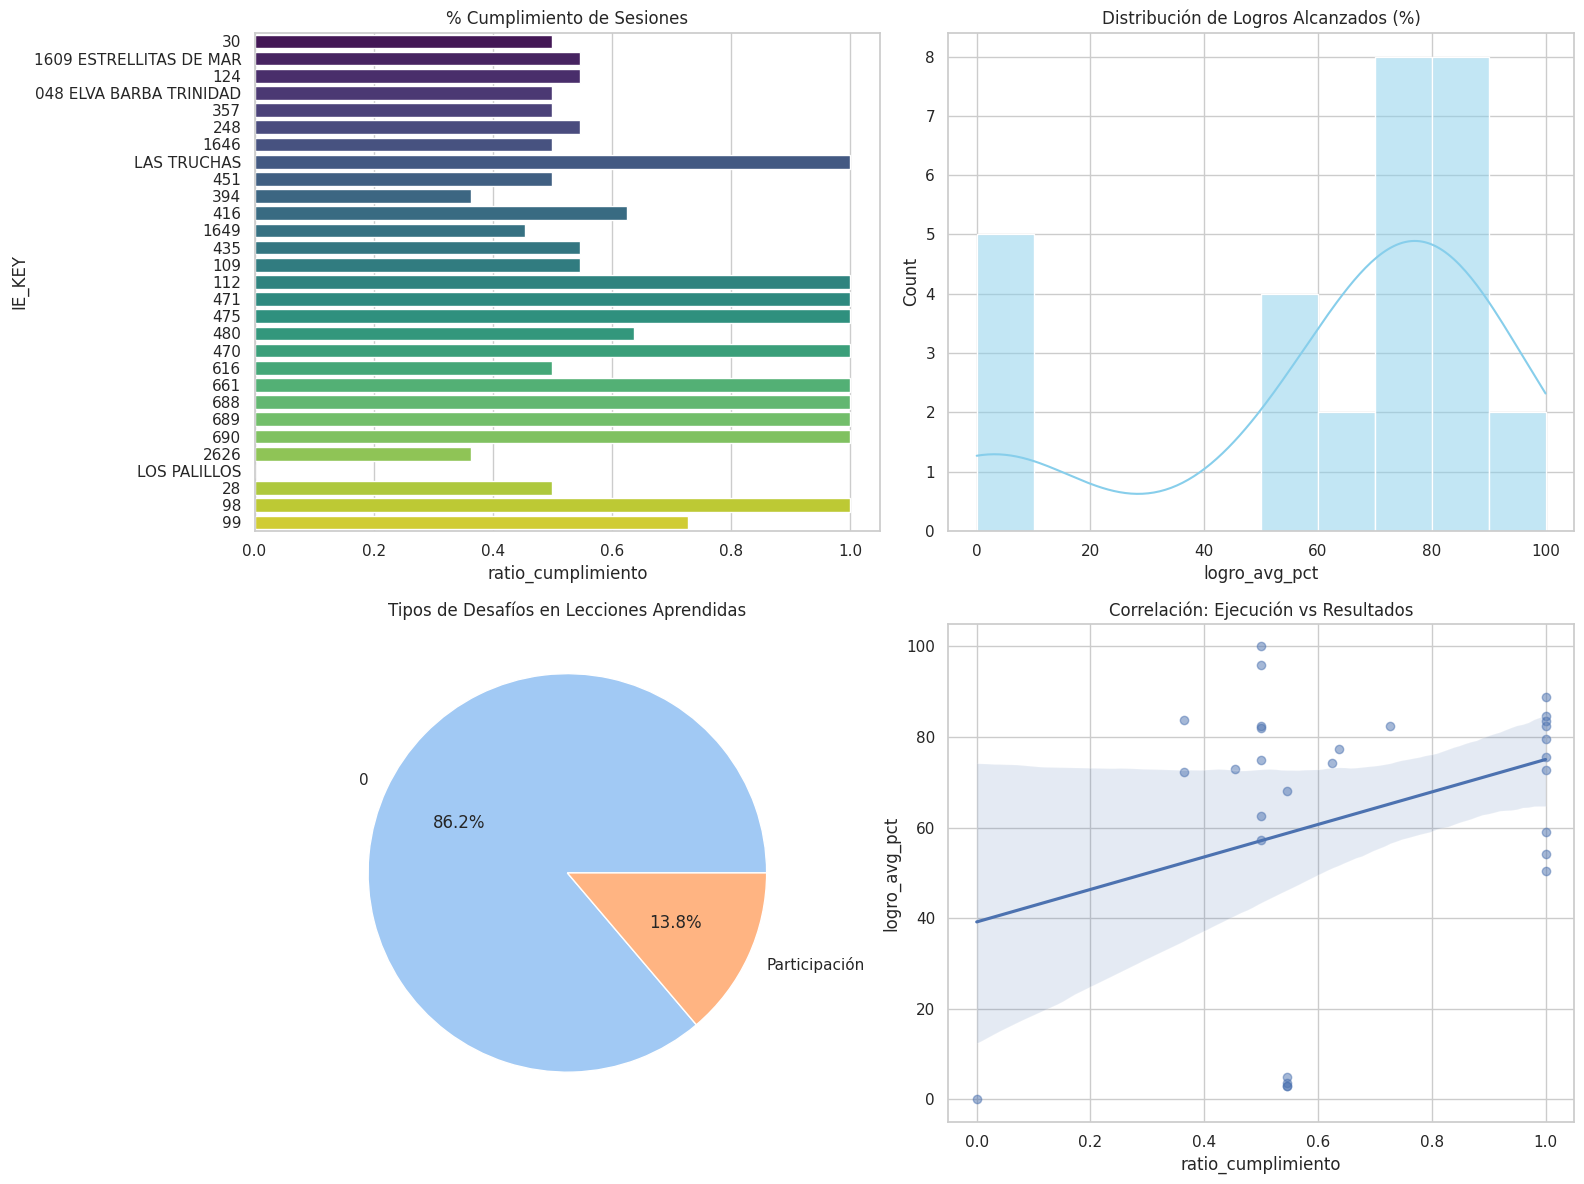

In [ ]:
if not df_final.empty:
    print("\n✅ Consolidación exitosa. Primeras filas:")
    print(df_final.head())

    # --- Generación de Gráficas ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Gráfica 1: Cumplimiento por Institución
    sns.barplot(data=df_final, x='ratio_cumplimiento', y='IE_KEY', ax=axes[0,0], palette='viridis')
    axes[0,0].set_title('% Cumplimiento de Sesiones')

    # Gráfica 2: Logro Académico (CASEL)
    sns.histplot(df_final['logro_avg_pct'], bins=10, kde=True, ax=axes[0,1], color='skyblue')
    axes[0,1].set_title('Distribución de Logros Alcanzados (%)')

    # Gráfica 3: Desafíos y su impacto en el sentimiento
    #sns.stripplot(data=df_final, x='categoria_desafio', y='sentimiento_leccion', size=8, ax=axes[1,0])
    #axes[1,0].set_title('Sentimiento de Lecciones por Categoría de Desafío')

    if 'categoria_desafio' in df_final.columns:
        counts = df_final['categoria_desafio'].value_counts()
        if not counts.empty:
            axes[1,0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
            axes[1,0].set_title('Tipos de Desafíos en Lecciones Aprendidas')

    # Gráfica 4: Relación Cumplimiento vs Logro
    sns.regplot(data=df_final, x='ratio_cumplimiento', y='logro_avg_pct', ax=axes[1,1], scatter_kws={'alpha':0.5})
    axes[1,1].set_title('Correlación: Ejecución vs Resultados')

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos para mostrar. Verifica que los archivos tengan 'Impacto', 'Lecciones' o 'ProgVSEjec' en el nombre.")


--- REPORTE CONSOLIDADO CON LLAVE MODULAR ---
   COD_MOD                   IE_KEY  ratio_cumplimiento_pct  logro_avg_pct
0  0000438                       30               50.000000      62.600000
1  0360305  1609 ESTRELLITAS DE MAR               54.545455      68.000000
2  0415745                      124               54.545455       5.000000
3  0415869  048 ELVA BARBA TRINIDAD               50.000000      75.000000
4  0469999                      357               50.000000      82.000000
5  0509711                      248               54.545455       3.666667
6  0750026                     1646               50.000000      57.272727
7  0783226              LAS TRUCHAS              100.000000      84.666667
8  1042829                      451               50.000000      96.000000
9  1043934                      394               36.363636      83.750000


/tmp/ipython-input-4239420871.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final.sort_values('ratio_cumplimiento_pct', ascending=False).head(IE_viz),


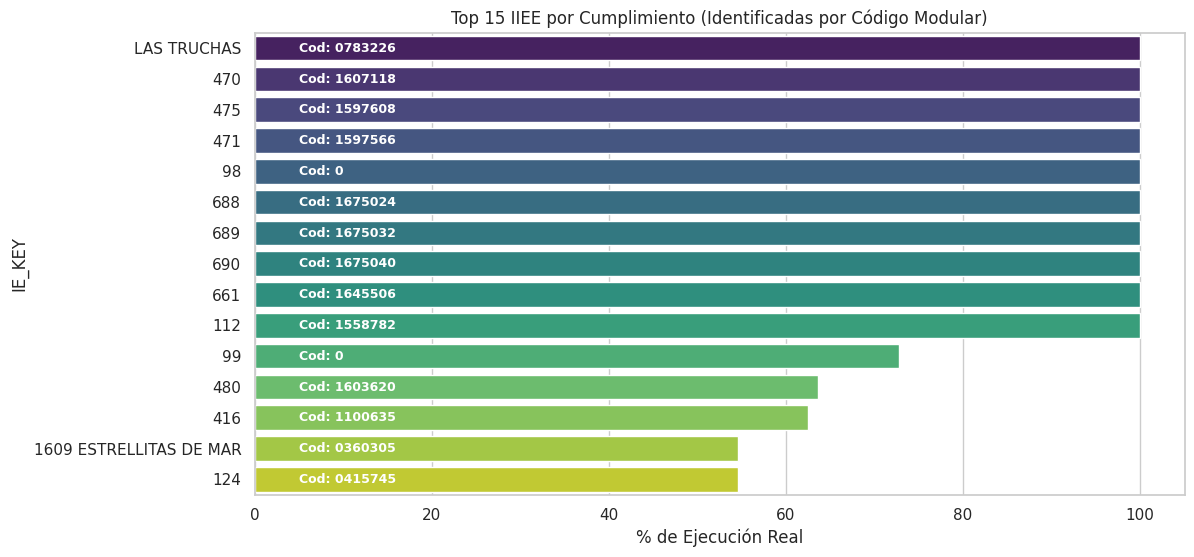

In [ ]:
if not df_final.empty:
    print("\n--- REPORTE CONSOLIDADO CON LLAVE MODULAR ---")
    # Mostrar columnas clave para verificar la relación
    cols_vista = [c for c in ['COD_MOD', 'IE_KEY', 'ratio_cumplimiento_pct', 'logro_avg_pct'] if c in df_final.columns]
    print(df_final[cols_vista].head(10))

    # Visualización
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))
    IE_viz = 15

    # Usamos COD_MOD en el eje Y para demostrar que la relación funciona
    sns.barplot(data=df_final.sort_values('ratio_cumplimiento_pct', ascending=False).head(IE_viz),
                x='ratio_cumplimiento_pct', y='IE_KEY', palette='viridis')

    # Añadimos etiquetas de COD_MOD a la gráfica
    for i, row in enumerate(df_final.sort_values('ratio_cumplimiento_pct', ascending=False).head(IE_viz).itertuples()):
        plt.text(5, i, f"Cod: {row.COD_MOD}", color='white', va='center', fontweight='bold', fontsize=9)

    plt.title(f'Top {IE_viz} IIEE por Cumplimiento (Identificadas por Código Modular)')
    plt.xlabel('% de Ejecución Real')
    plt.show()
else:
    print("No se pudo generar el reporte consolidado.")